In [1]:
import numpy as np 
from skimage import io, data, filters, morphology, measure, segmentation, color, restoration
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import clear_output
from bioio import BioImage
import xarray as xr
from pathlib import Path
import os
import glob

In [2]:
# simple matplotlib method to plot an image 
def plotImage(img, title):
    fig, axes = plt.subplots(1, 1, figsize=(12, 6))

    axes.imshow(img, cmap="gray")
    axes.set_title(title)
    #axes.axis("off")

    plt.tight_layout
    plt.show()

In [3]:
# matplotlib method to plot 2 images side by side where 1 is usually original and and 2 is usually following some transformation
def plot_before_after(img1, title1, img2, title2):
    fig, (ax1, ax2) = plt.subplots(1, 2, sharex=True, sharey=True, 
                                   figsize=(12, 6))
    ax1.imshow(img1, cmap="gray")
    ax1.set_title(title1)

    ax2.imshow(img2, cmap="gray")
    ax2.set_title(title2)

    plt.tight_layout
    plt.show()

In [4]:
# matplotlib method to plot original image and image with masked overlay
def plot_masked(img1, title, mask, overlay_color):
    fig, (ax1, ax2) = plt.subplots(1, 2, sharex=True, sharey=True, 
                                figsize=(12, 6))
    
    ax1.imshow(img1, cmap="gray")
    ax1.set_title(title)

    ax2.imshow(img1, cmap="gray")
    ax2.imshow(mask, cmap= overlay_color, alpha=0.5)
    ax2.set_title("masked")

    plt.tight_layout
    plt.show()

In [5]:
# returning summary statistics for each image 
def summary_stats(smoothed_img, mask):
    roi_pixels = smoothed_img[mask>0]

    if roi_pixels.size == 0:
        return None
    else:
        mean_val = float(np.mean(roi_pixels))
        stdev_val = float(np.std(roi_pixels))
        min_val = float(np.min(roi_pixels))
        max_val = float(np.max(roi_pixels))

        print(" mean:      {:7.4f}".format(mean_val)   )
        print(" stdev:     {:7.4f}".format(stdev_val)  )
        print(" min:       {:7.4f}".format(min_val)    )
        print(" max:       {:7.4f}".format(max_val)    )

        return mean_val, stdev_val, min_val, max_val

In [ ]:
# test developing file reading method
filelist = []
for root, dirs, files in Path('output2').walk(on_error=print):
  print(
      root,
      "consumes",
      sum((root / file).stat().st_size for file in files),
      "bytes in",
      len(files),
      "non-directory files",
      files,
  )
  filelist.extend(root / file for file in files if file.endswith('ome.tif'))

if '__pycache__' in dirs:
    dirs.remove('__pycache__')

print(len(filelist))

In [6]:
# threshold signal from an image using a manual value 
def thresh_signal(channel, thresh_val):
    # define signal and background ROI

    threshold_value = thresh_val
    binary_mask = channel > threshold_value
    plot_masked(channel, "Original", binary_mask, "OrRd")
    
    return binary_mask

In [7]:
# threshold and plot the background signal given input of channel, lower limit (thresh_low), and upper limit (thresh_high)
def thresh_back(channel, thresh_low, thresh_val):
    
    mask = (channel > thresh_low) & (channel < thresh_val)
    plot_masked(channel, "CD4 signal", mask, "BuPu")

    return mask

In [ ]:
# load image and define signal channel
# -----------------------------------------------------------

# input var: filelist, file index, channel index, threshold value lo, threshold value hi 
# output var: sig_stats, back_stats, filename


def threshold_channel(filelist, idx, chIdx, threshLo, threshHi):

    full_image = BioImage(filelist[idx]) 
    imgname = filelist[idx].parts[-1] # get the filename from the filelist which is image name 
    print(imgname)
    ximg = full_image.xarray_data
    print(ximg.coords)
    aximg = ximg.isel(C=chIdx).squeeze(drop=True)
    print(f"channel dimensions (Y,X): {aximg.shape}")
    naximg = np.asarray(aximg)

    # define signal and background ROI + general stats from each
    # -----------------------------------------------------------
    print("thresholding signal...")
    sig_mask = thresh_signal(naximg, threshHi)
    #print("Signal summary")
    sig_stats = summary_stats(naximg, sig_mask)

    print("thresholding backround...")
    back_mask = thresh_back(naximg, threshLo, threshHi)
    print("Background summary")
    back_stats = summary_stats(naximg, back_mask)

    return imgname, sig_stats, back_stats 

threshold_channel(filelist, 0, 0, 1, 10000)

NameError: name 'filelist' is not defined

In [9]:
# load all .ome.tifs from subdirectoris in a specified path 
def load_files(path):
    filelist = []
    for root, dirs, files in Path(path).walk(on_error=print):
        print(
            root,
            "consumes",
            sum((root / file).stat().st_size for file in files),
            "bytes in",
            len(files),
            "non-directory files",
            files,
        )
        filelist.extend(root / file for file in files if file.endswith('ome.tif'))

    if '__pycache__' in dirs:
        dirs.remove('__pycache__')

    return filelist

In [11]:
# define empty dictionary of results containing desired summary statistics 
def clear_results():
    results = {
            "image_name"         : [],
            "signal_mean"        : [],
            "signal_stdev"       : [],
            "bckgrnd_mean"       : [],
            "bckgrnd_stdev"      : [],
            "sig_noise_ratio"    : [], 
            }
    return results  

output/CD31_ligM2/images/100 consumes 6148 bytes in 1 non-directory files ['.DS_Store']
output/CD31_ligM2/images/100/100_20x_0-0 consumes 3761304 bytes in 1 non-directory files ['100_20x_0-0.ome.tif']
output/CD31_ligM2/images/100/100_20x_1-0 consumes 4007557 bytes in 1 non-directory files ['100_20x_1-0.ome.tif']
output/CD31_ligM2/images/100/100_20x_2-0 consumes 3537420 bytes in 1 non-directory files ['100_20x_2-0.ome.tif']
100_20x_1-0.ome.tif
Coordinates:
  * C        (C) <U4 32B 'Ch_0' 'Ch_1'
  * Z        (Z) float64 8B 0.0
  * Y        (Y) float64 8kB 0.0 0.3409 0.6818 1.023 ... 327.9 328.3 328.6 329.0
  * X        (X) float64 10kB 0.0 0.3409 0.6818 1.023 ... 440.8 441.1 441.5
channel dimensions (Y,X): (966, 1296)
thresholding signal...


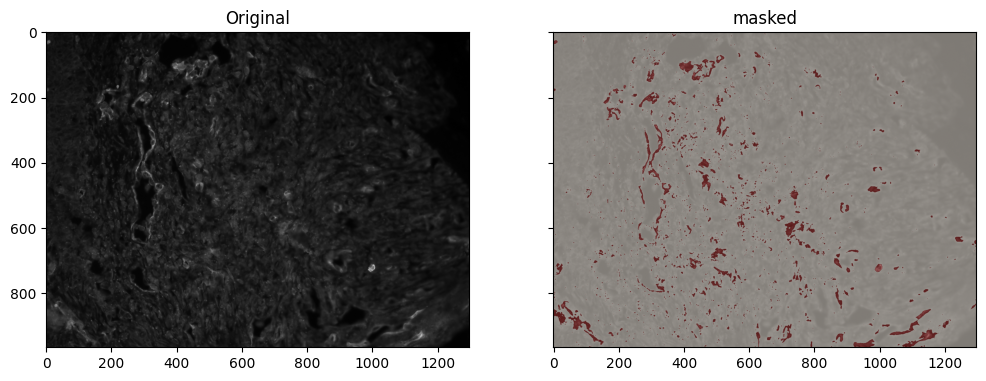

 mean:      18740.7531
 stdev:     4423.0397
 min:       15004.0000
 max:       65535.0000
thresholding backround...


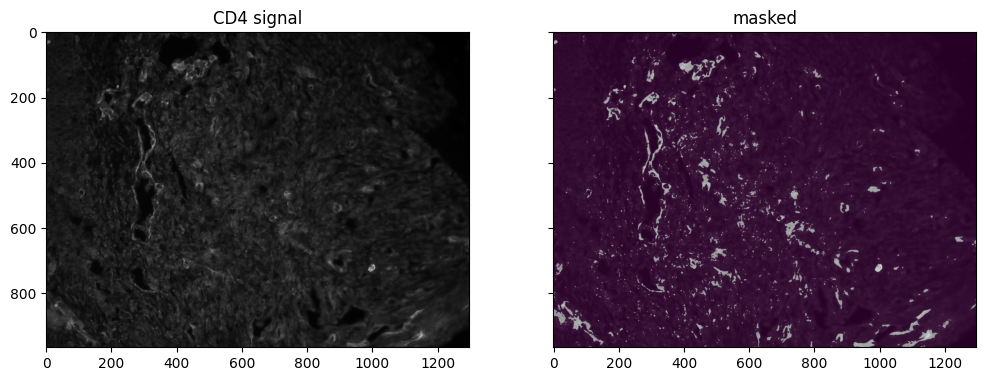

Background summary
 mean:      7713.7105
 stdev:     2824.8188
 min:       1212.0000
 max:       14996.0000


In [25]:
path = "output/CD31_ligM2/images/100"
filelist = load_files(path)
image_name, signal, background = threshold_channel(filelist, 1, 1, 0, 15000)

In [12]:
# Threshold entire specified directory

def threshold_titer(in_dir, chIdx, threshLo, threshHi):
    results = clear_results()
    filelist = load_files(in_dir)
    print(f"length of filelist: {len(filelist)}")

    for i in range(len(filelist)):
        file_name, sig_stats, back_stats = threshold_channel(filelist, i, chIdx, threshLo, threshHi)

        if sig_stats is not None:    
        # Export to results dict
            results["image_name"].append(file_name)
            results["signal_mean"].append(sig_stats[0])      # Mean from signal stats
            results["signal_stdev"].append(sig_stats[1])     # Stdev from signal stats
            results["bckgrnd_mean"].append(back_stats[0])    # Mean from background stats
            results["bckgrnd_stdev"].append(back_stats[1])   # Stdev from background stats
            results["sig_noise_ratio"].append((sig_stats[0]- back_stats[0]) / (back_stats[1])) # Signal to noise ratio
            
            clear_output(wait=True)
        else:
            # Export to results dict
            results["image_name"].append(file_name)
            results["signal_mean"].append(0)        # Mean from signal stats
            results["signal_stdev"].append(0)       # Stdev from signal stats
            results["bckgrnd_mean"].append(0)       # Mean from background stats
            results["bckgrnd_stdev"].append(0)      # Stdev from background stats
            results["sig_noise_ratio"].append(0)    # Siganl to noise ratio
            
            clear_output(wait=True)
    
    return results

800_20x_0-0.ome.tif
Coordinates:
  * C        (C) <U4 32B 'Ch_0' 'Ch_1'
  * Z        (Z) float64 8B 0.0
  * Y        (Y) float64 8kB 0.0 0.3409 0.6818 1.023 ... 327.9 328.3 328.6 329.0
  * X        (X) float64 10kB 0.0 0.3409 0.6818 1.023 ... 440.8 441.1 441.5
channel dimensions (Y,X): (966, 1296)
thresholding signal...


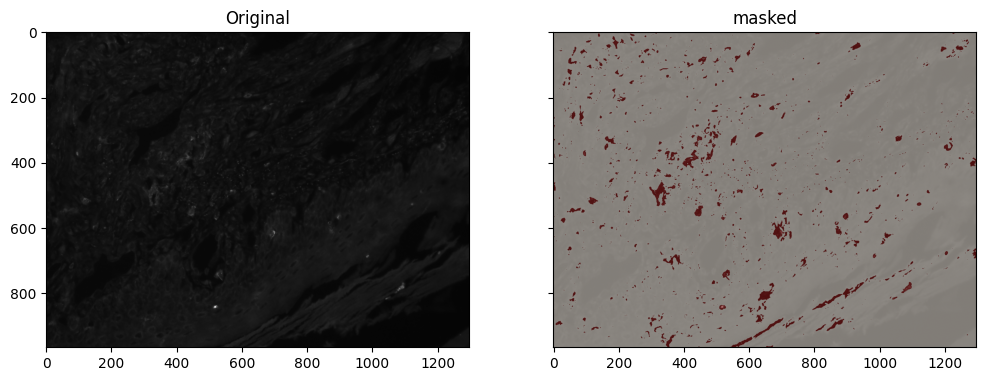

 mean:      9427.5824
 stdev:     2499.7573
 min:       8004.0000
 max:       65535.0000
thresholding backround...


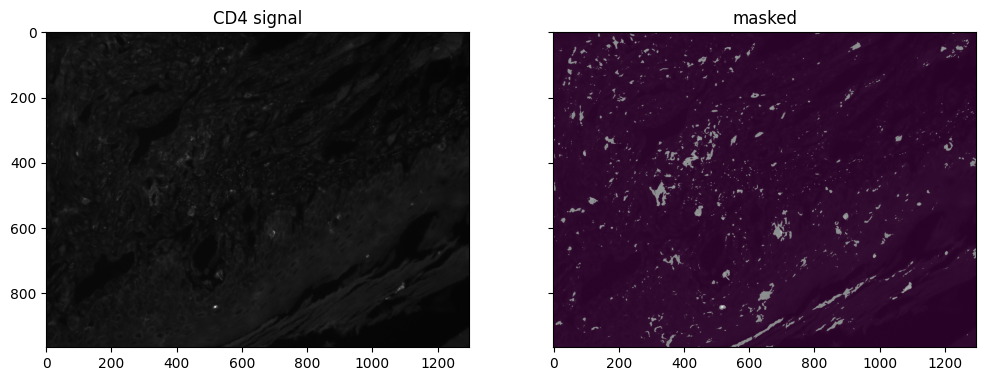

Background summary
 mean:      4885.8138
 stdev:     1453.1078
 min:       440.0000
 max:       7996.0000


In [26]:
results = threshold_titer('output/CD11c_ligM2/images/800', 1, 1, 8000)

In [ ]:
# Export to results dict
results["image_name"].append(file_name)
results["signal_mean"].append(sig_stats[0])      # Mean from signal stats
results["signal_stdev"].append(sig_stats[1])     # Stdev from signal stats
results["bckgrnd_mean"].append(back_stats[0])    # Mean from background stats
results["bckgrnd_stdev"].append(back_stats[1])   # Stdev from background stats
results["sig_noise_ratio"].append((sig_stats[0]- back_stats[0]) / back_stats[1])    # Siganl to noise ratio

In [23]:
# Save results dataframe as a .csv
df = pd.DataFrame(results)
df.to_csv('titers_cd31_ligM2_800_demo.csv', index = False) 